# GPU Training Performance Analysis: Mixed Precision Comparison

This notebook analyzes training performance across different GPUs (RTX 4090, L40S, RX 7900 XT) and precision formats (FP32, FP16, BF16) for various deep learning models (BERT-Large, GPT-2, ResNet50).

## Analysis Objectives:
1. **Precision Impact**: Evaluate performance improvements when moving from FP32 to FP16/BF16
2. **GPU Performance**: Compare throughput and efficiency across different GPUs
3. **Model-Specific Behavior**: Analyze how different models respond to precision changes
4. **Energy Efficiency**: Evaluate power consumption and energy efficiency metrics
5. **Memory Utilization**: Compare memory usage across precisions and GPUs

## 1. Setup and Data Loading

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
def load_all_metrics(directory):
    """
    Load all JSON files from the epoch_metrics directory.
    Returns a pandas DataFrame with all metrics.
    """
    all_data = []
    json_files = glob.glob(str(Path(directory) / '*.json'))
    
    print(f"Found {len(json_files)} JSON files")
    
    for file_path in json_files:
        with open(file_path, 'r') as f:
            # Read all lines (each line is a JSON object)
            for line in f:
                if line.strip():  # Skip empty lines
                    data = eval(line.strip())  # Convert string representation to dict
                    all_data.append(data)
    
    df = pd.DataFrame(all_data)
    
    # Add derived metrics
    df['energy_per_sample'] = df['power_watts'] * df['epoch_time_sec'] / df['samples']  # Joules per sample
    df['throughput_efficiency'] = df['samples_per_sec'] / df['power_watts']  # samples/sec/watt
    df['mem_alloc_gb'] = df['mem_alloc_bytes'] / (1024**3)
    df['mem_reserved_gb'] = df['mem_reserved_bytes'] / (1024**3)
    df['max_mem_alloc_gb'] = df['max_mem_alloc_bytes'] / (1024**3)
    
    # Clean up GPU names for better display
    df['gpu_short_name'] = df['gpu_name'].str.replace('NVIDIA GeForce ', '').str.replace('NVIDIA ', '').str.replace('Radeon ', '')
    
    return df

# Load the data
data_dir = Path('epoch_metrics')
df = load_all_metrics(data_dir)

print(f"\nLoaded {len(df)} records")
print(f"\nGPUs: {df['gpu_short_name'].unique()}")
print(f"Models: {df['model'].unique()}")
print(f"Precisions: {df['precision'].unique()}")
print(f"\nDataFrame shape: {df.shape}")
df.head()

Found 28 JSON files

Loaded 26381 records

GPUs: ['L40S' 'RX 7900 XT' 'RTX 4090']
Models: ['resnet50' 'bert-large' 'gpt2']
Precisions: ['fp16' 'fp32' 'bf16']

DataFrame shape: (26381, 26)


,experiment_num,gpu_vendor,gpu_name,model,precision,batch_size,epoch,loss,epoch_time_sec,samples,...,max_mem_reserved_bytes,gpu_util_percent,mem_util_percent,power_watts,energy_per_sample,throughput_efficiency,mem_alloc_gb,mem_reserved_gb,max_mem_alloc_gb,gpu_short_name
0,1,nvidia,NVIDIA L40S,resnet50,fp16,96,1,2.306783,8.289907,9600,...,5289017344,98,91,315.619,0.272547,3.669091,0.426441,4.925781,4.346987,L40S
1,1,nvidia,NVIDIA L40S,resnet50,fp16,96,2,2.294169,7.905766,9600,...,5289017344,97,91,311.423,0.256462,3.899209,0.426441,4.925781,4.346987,L40S
2,1,nvidia,NVIDIA L40S,resnet50,fp16,96,3,2.311544,7.902498,9600,...,5289017344,97,92,317.180,0.261095,3.830020,0.426441,4.925781,4.346987,L40S
3,1,nvidia,NVIDIA L40S,resnet50,fp16,96,4,2.304525,7.903141,9600,...,5289017344,97,91,315.503,0.259736,3.850065,0.426441,4.925781,4.346987,L40S
4,1,nvidia,NVIDIA L40S,resnet50,fp16,96,5,2.306559,7.904081,9600,...,5289017344,97,94,316.728,0.260775,3.834718,0.426441,4.925781,4.346987,L40S


## 2. Data Summary and Statistics

In [3]:
# Calculate summary statistics per configuration
summary = df.groupby(['gpu_short_name', 'model', 'precision']).agg({
    'samples_per_sec': ['mean', 'std'],
    'epoch_time_sec': ['mean', 'std'],
    'power_watts': ['mean', 'std'],
    'energy_per_sample': ['mean', 'std'],
    'throughput_efficiency': ['mean', 'std'],
    'gpu_util_percent': ['mean', 'std'],
    'mem_util_percent': ['mean', 'std'],
    'max_mem_alloc_gb': ['mean', 'max'],
    'loss': ['mean', 'std']
}).round(3)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

print("Summary Statistics:")
summary

Summary Statistics:


,gpu_short_name,model,precision,samples_per_sec_mean,samples_per_sec_std,epoch_time_sec_mean,epoch_time_sec_std,power_watts_mean,power_watts_std,energy_per_sample_mean,...,throughput_efficiency_mean,throughput_efficiency_std,gpu_util_percent_mean,gpu_util_percent_std,mem_util_percent_mean,mem_util_percent_std,max_mem_alloc_gb_mean,max_mem_alloc_gb_max,loss_mean,loss_std
0,L40S,bert-large,bf16,368.611,0.594,26.044,0.042,315.762,3.164,0.857,...,1.167,0.012,99.092,0.492,8.143600e+01,1.988,16.431,16.431,0.700,0.013
1,L40S,bert-large,fp16,362.846,0.674,70.554,0.131,312.752,5.342,0.862,...,1.161,0.020,99.801,0.399,9.240400e+01,0.675,36.605,36.605,0.697,0.007
2,L40S,bert-large,fp32,237.241,0.412,80.931,0.141,330.725,9.488,1.394,...,0.718,0.021,100.000,0.000,8.151100e+01,1.340,41.625,41.625,0.696,0.007
3,L40S,gpt2,bf16,376.573,3.607,8.498,0.082,314.485,3.651,0.835,...,1.198,0.013,97.391,1.214,9.217900e+01,1.185,7.551,7.553,10.837,0.011
4,L40S,gpt2,fp16,362.379,2.625,8.831,0.064,309.626,4.824,0.854,...,1.171,0.018,96.015,1.150,9.062100e+01,1.079,7.551,7.553,10.835,0.011
5,L40S,gpt2,fp32,317.799,0.391,40.277,0.050,307.690,14.406,0.968,...,1.035,0.048,99.995,0.084,9.362800e+01,2.069,31.074,31.074,10.842,0.007
6,L40S,resnet50,bf16,1188.661,21.742,5.386,0.099,319.408,4.444,0.269,...,3.722,0.064,95.204,2.231,8.148300e+01,2.175,3.015,3.015,2.308,0.015
7,L40S,resnet50,fp16,1213.278,6.930,7.913,0.047,314.717,2.302,0.259,...,3.855,0.032,97.153,0.602,9.208900e+01,1.268,4.347,4.347,2.307,0.009
8,L40S,resnet50,fp32,685.910,23.446,4.671,0.159,314.346,8.187,0.459,...,2.182,0.056,92.516,4.047,8.736600e+01,4.016,2.890,2.890,2.312,0.023
9,RTX 4090,bert-large,bf16,362.992,0.485,35.263,0.048,367.634,0.975,1.013,...,0.987,0.003,98.649,0.618,6.650200e+01,2.998,20.466,20.466,0.699,0.010


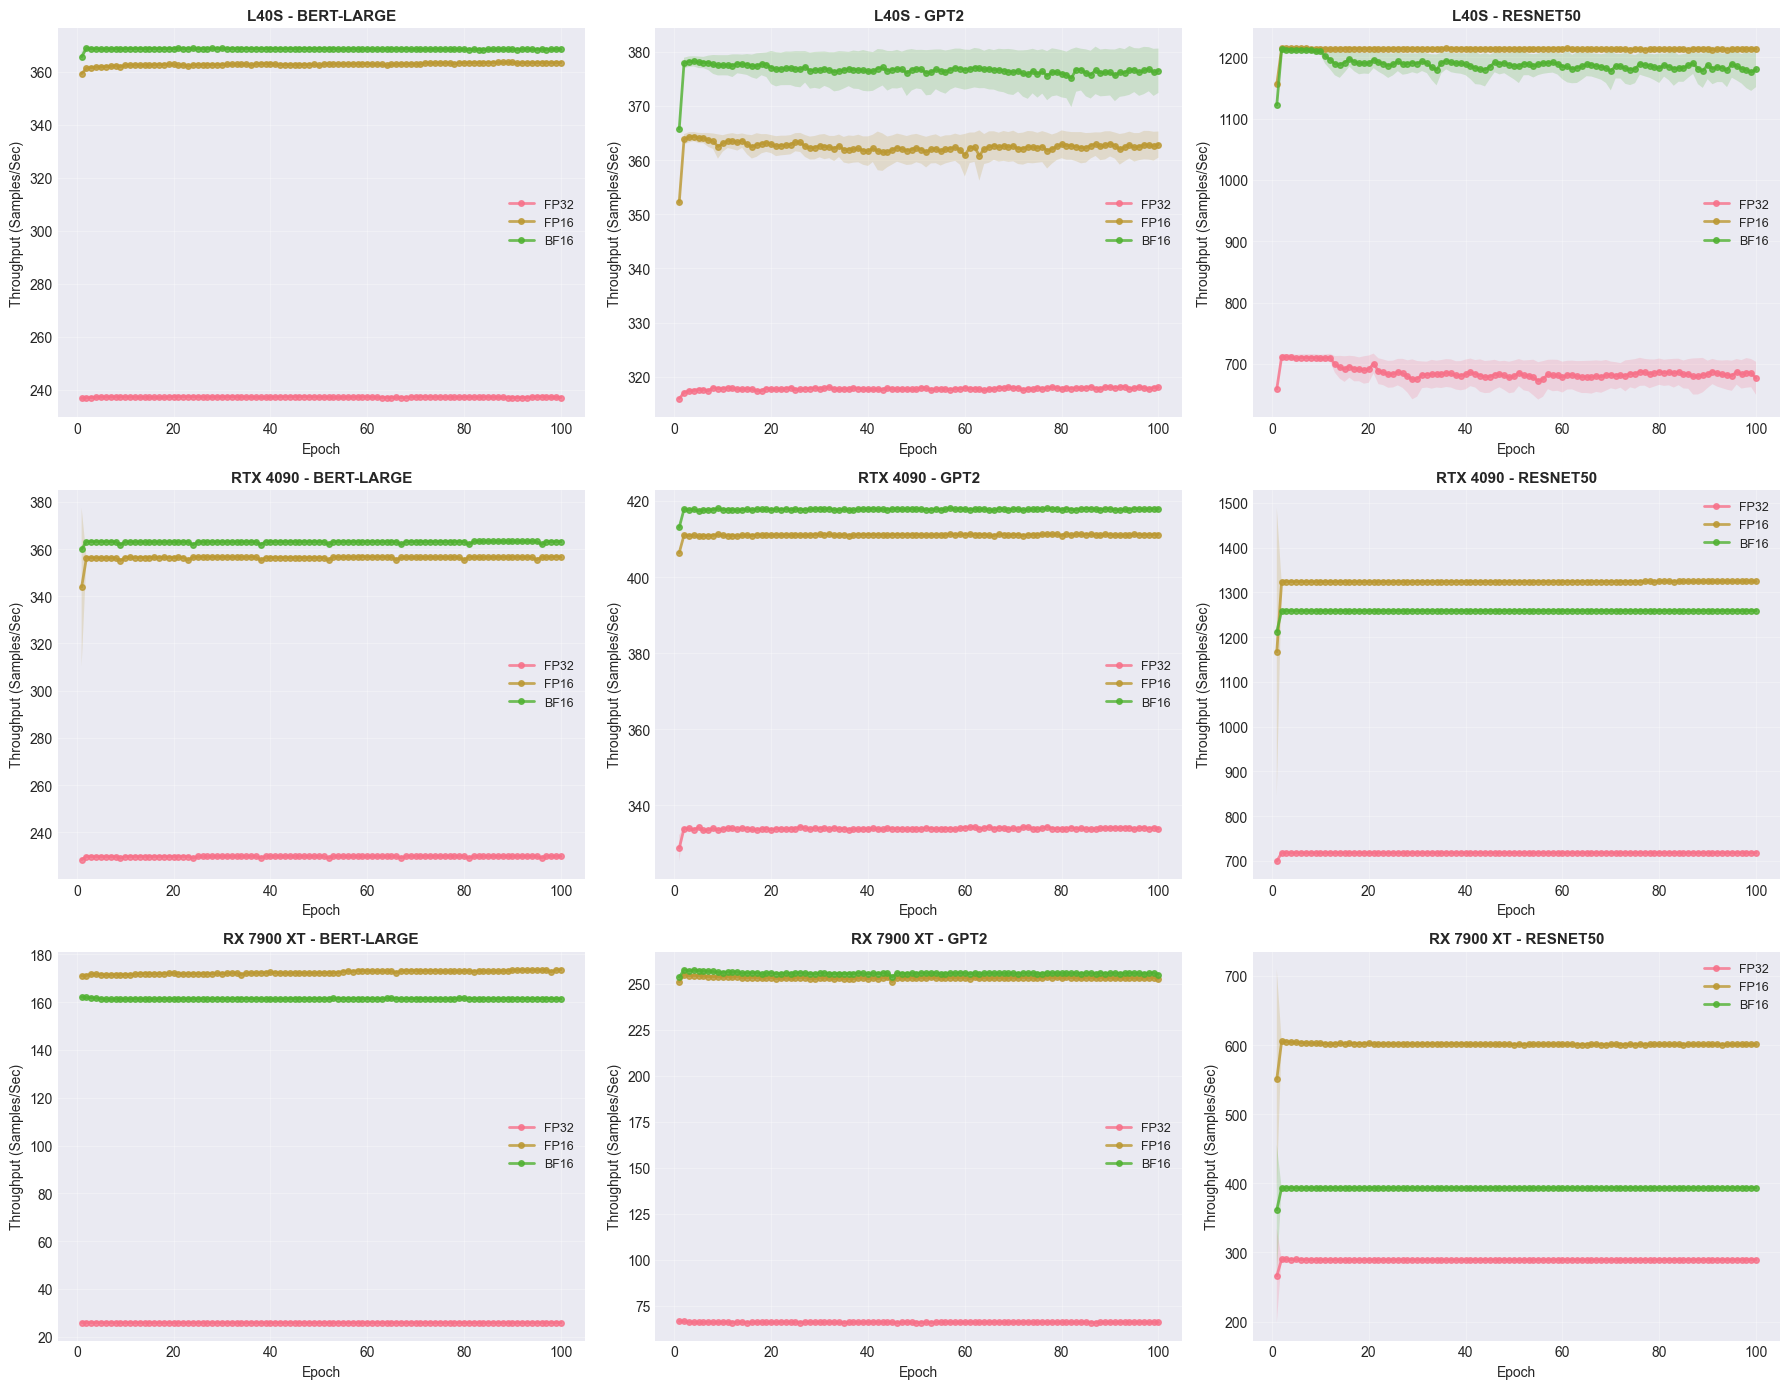


Throughput stability over epochs:

L40S:
  bert-large (fp32): 237.2 ± 0.4 samples/sec (CV: 0.17%)
  bert-large (fp16): 362.8 ± 0.7 samples/sec (CV: 0.19%)
  bert-large (bf16): 368.6 ± 0.6 samples/sec (CV: 0.16%)
  gpt2 (fp32): 317.8 ± 0.4 samples/sec (CV: 0.12%)
  gpt2 (fp16): 362.4 ± 2.6 samples/sec (CV: 0.72%)
  gpt2 (bf16): 376.6 ± 3.6 samples/sec (CV: 0.96%)
  resnet50 (fp32): 685.9 ± 23.4 samples/sec (CV: 3.42%)
  resnet50 (fp16): 1213.3 ± 6.9 samples/sec (CV: 0.57%)
  resnet50 (bf16): 1188.7 ± 21.7 samples/sec (CV: 1.83%)

RTX 4090:
  bert-large (fp32): 229.7 ± 0.2 samples/sec (CV: 0.10%)
  bert-large (fp16): 356.1 ± 4.9 samples/sec (CV: 1.39%)
  bert-large (bf16): 363.0 ± 0.5 samples/sec (CV: 0.13%)
  gpt2 (fp32): 333.9 ± 0.6 samples/sec (CV: 0.19%)
  gpt2 (fp16): 411.0 ± 0.5 samples/sec (CV: 0.12%)
  gpt2 (bf16): 417.7 ± 0.5 samples/sec (CV: 0.12%)
  resnet50 (fp32): 717.6 ± 1.9 samples/sec (CV: 0.26%)
  resnet50 (fp16): 1322.3 ± 34.3 samples/sec (CV: 2.60%)
  resnet50 (bf16):

In [17]:
# Visualize throughput over epochs with standard deviation
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_idx = 0
for gpu in sorted(df['gpu_short_name'].unique()):
    for model in sorted(df['model'].unique()):
        ax = axes[plot_idx]
        
        for precision in ['fp32', 'fp16', 'bf16']:
            subset = df[(df['gpu_short_name'] == gpu) & 
                       (df['model'] == model) & 
                       (df['precision'] == precision)]
            
            if len(subset) > 0:
                # Group by epoch and calculate mean and std
                epoch_stats = subset.groupby('epoch')['samples_per_sec'].agg(['mean', 'std']).reset_index()
                
                # Plot mean line
                ax.plot(epoch_stats['epoch'], epoch_stats['mean'], 
                       label=precision.upper(), linewidth=2, marker='o', 
                       markersize=4, alpha=0.8)
                
                # Add shaded region for standard deviation
                ax.fill_between(epoch_stats['epoch'], 
                               epoch_stats['mean'] - epoch_stats['std'],
                               epoch_stats['mean'] + epoch_stats['std'],
                               alpha=0.2)
        
        ax.set_title(f'{gpu} - {model.upper()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Throughput (Samples/Sec)', fontsize=10)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1

plt.tight_layout()
plt.savefig('throughput_vs_epoch_with_std.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThroughput stability over epochs:")
for gpu in sorted(df['gpu_short_name'].unique()):
    print(f"\n{gpu}:")
    for model in sorted(df['model'].unique()):
        for precision in ['fp32', 'fp16', 'bf16']:
            subset = df[(df['gpu_short_name'] == gpu) & 
                       (df['model'] == model) & 
                       (df['precision'] == precision)]
            if len(subset) > 0:
                overall_mean = subset['samples_per_sec'].mean()
                overall_std = subset['samples_per_sec'].std()
                cv = (overall_std / overall_mean * 100)
                print(f"  {model} ({precision}): {overall_mean:.1f} ± {overall_std:.1f} samples/sec (CV: {cv:.2f}%)")

## 3. Precision Improvement Analysis

### 3.1 Speedup from FP32 to FP16/BF16

In [4]:
def calculate_speedup(df):
    """
    Calculate speedup relative to FP32 baseline for each GPU and model.
    """
    speedup_data = []
    
    for gpu in df['gpu_short_name'].unique():
        for model in df['model'].unique():
            # Get FP32 baseline
            fp32_data = df[(df['gpu_short_name'] == gpu) & 
                          (df['model'] == model) & 
                          (df['precision'] == 'fp32')]
            
            if len(fp32_data) == 0:
                continue
                
            fp32_throughput = fp32_data['samples_per_sec'].mean()
            fp32_energy = fp32_data['energy_per_sample'].mean()
            
            # Calculate speedup for other precisions
            for precision in ['fp16', 'bf16']:
                prec_data = df[(df['gpu_short_name'] == gpu) & 
                              (df['model'] == model) & 
                              (df['precision'] == precision)]
                
                if len(prec_data) > 0:
                    prec_throughput = prec_data['samples_per_sec'].mean()
                    prec_energy = prec_data['energy_per_sample'].mean()
                    
                    speedup_data.append({
                        'gpu': gpu,
                        'model': model,
                        'precision': precision,
                        'throughput_speedup': prec_throughput / fp32_throughput,
                        'energy_reduction': (fp32_energy - prec_energy) / fp32_energy * 100,
                        'fp32_throughput': fp32_throughput,
                        'prec_throughput': prec_throughput
                    })
    
    return pd.DataFrame(speedup_data)

speedup_df = calculate_speedup(df)
print("\nSpeedup Analysis (relative to FP32):")
speedup_df.round(3)


Speedup Analysis (relative to FP32):


,gpu,model,precision,throughput_speedup,energy_reduction,fp32_throughput,prec_throughput
0,L40S,resnet50,fp16,1.769,43.431,685.910,1213.278
1,L40S,resnet50,bf16,1.733,41.387,685.910,1188.661
2,L40S,bert-large,fp16,1.529,38.170,237.241,362.846
3,L40S,bert-large,bf16,1.554,38.551,237.241,368.611
4,L40S,gpt2,fp16,1.140,11.749,317.799,362.379
5,L40S,gpt2,bf16,1.185,13.741,317.799,376.573
6,RX 7900 XT,resnet50,fp16,2.080,52.033,288.937,600.871
7,RX 7900 XT,resnet50,bf16,1.360,28.007,288.937,392.886
8,RX 7900 XT,bert-large,fp16,6.655,84.564,25.915,172.462
9,RX 7900 XT,bert-large,bf16,6.229,83.625,25.915,161.429


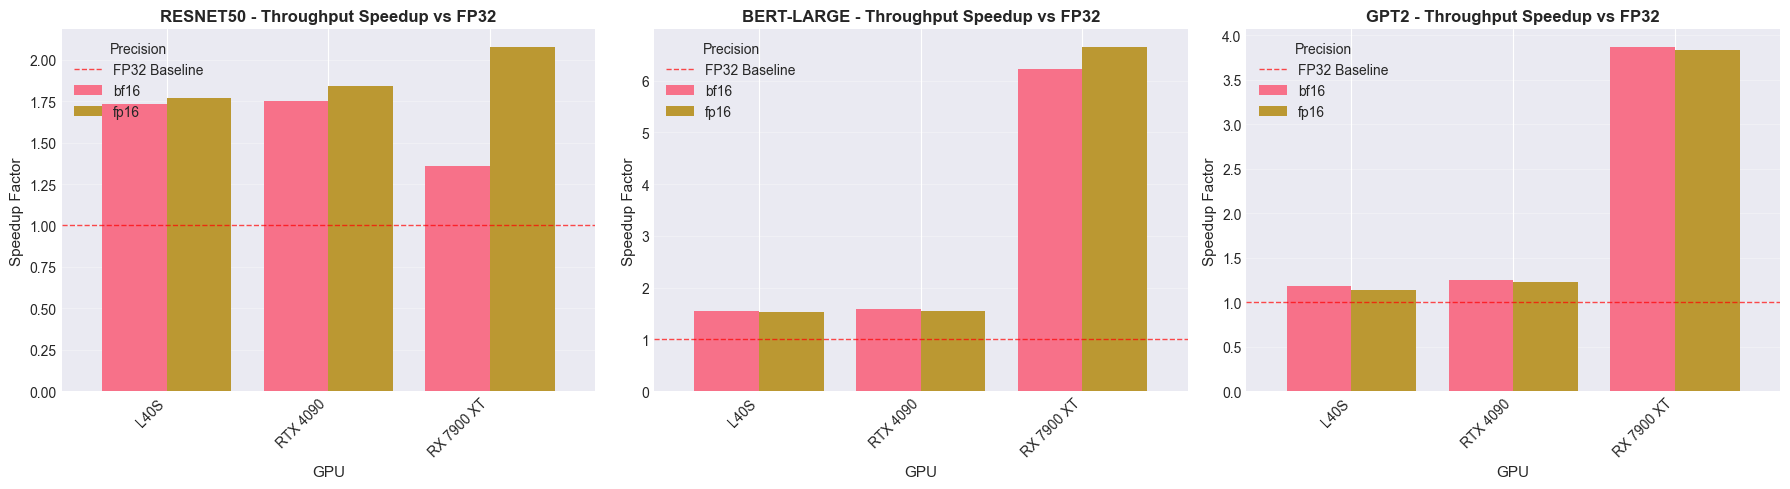


Average speedup by precision:
            mean    min    max
precision                     
bf16       2.280  1.185  6.229
fp16       2.403  1.140  6.655


In [5]:
# Visualize throughput speedup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model in enumerate(df['model'].unique()):
    model_data = speedup_df[speedup_df['model'] == model]
    
    if len(model_data) > 0:
        pivot_data = model_data.pivot(index='gpu', columns='precision', values='throughput_speedup')
        
        pivot_data.plot(kind='bar', ax=axes[idx], width=0.8)
        axes[idx].set_title(f'{model.upper()} - Throughput Speedup vs FP32', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('GPU', fontsize=11)
        axes[idx].set_ylabel('Speedup Factor', fontsize=11)
        axes[idx].axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='FP32 Baseline')
        axes[idx].legend(title='Precision', loc='upper left')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('throughput_speedup_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAverage speedup by precision:")
print(speedup_df.groupby('precision')['throughput_speedup'].agg(['mean', 'min', 'max']).round(3))

### 3.2 Energy Efficiency Improvement

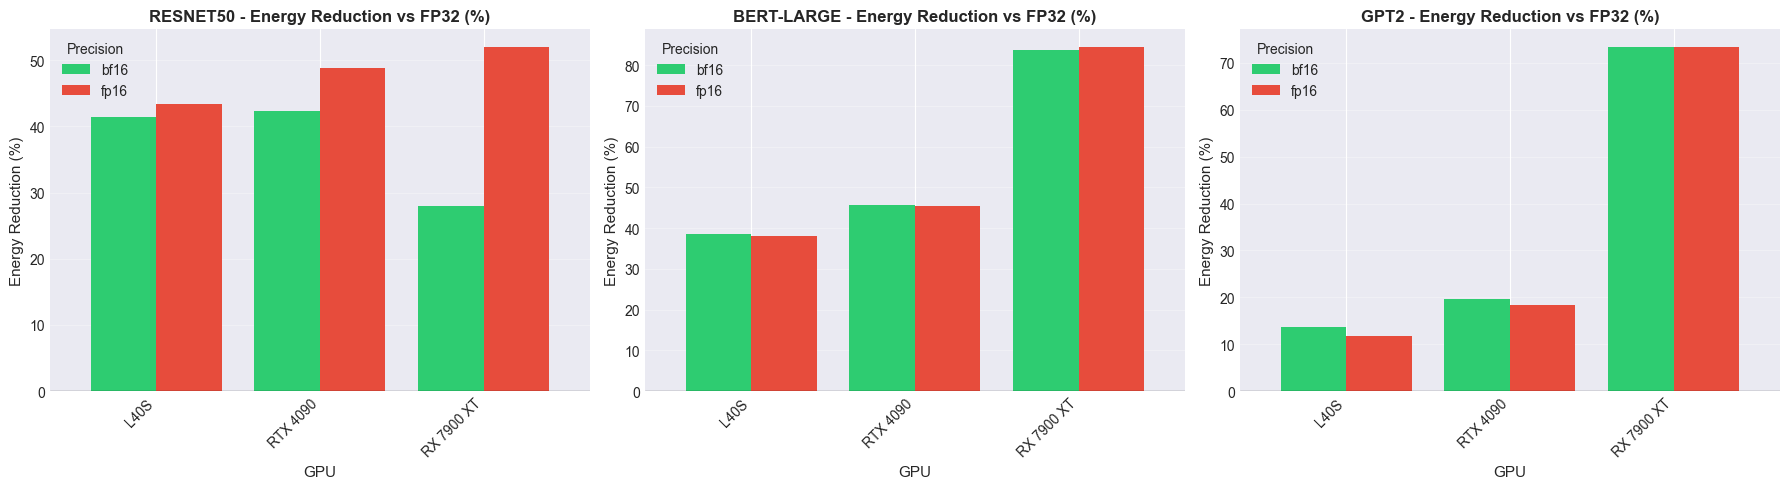


Average energy reduction by precision (%):
            mean    min    max
precision                     
bf16       42.93  13.74  83.63
fp16       46.19  11.75  84.56


In [6]:
# Visualize energy reduction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model in enumerate(df['model'].unique()):
    model_data = speedup_df[speedup_df['model'] == model]
    
    if len(model_data) > 0:
        pivot_data = model_data.pivot(index='gpu', columns='precision', values='energy_reduction')
        
        pivot_data.plot(kind='bar', ax=axes[idx], width=0.8, color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'{model.upper()} - Energy Reduction vs FP32 (%)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('GPU', fontsize=11)
        axes[idx].set_ylabel('Energy Reduction (%)', fontsize=11)
        axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        axes[idx].legend(title='Precision', loc='upper left')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('energy_reduction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAverage energy reduction by precision (%):")  
print(speedup_df.groupby('precision')['energy_reduction'].agg(['mean', 'min', 'max']).round(2))

## 4. GPU Performance Comparison

### 4.1 Absolute Throughput Comparison

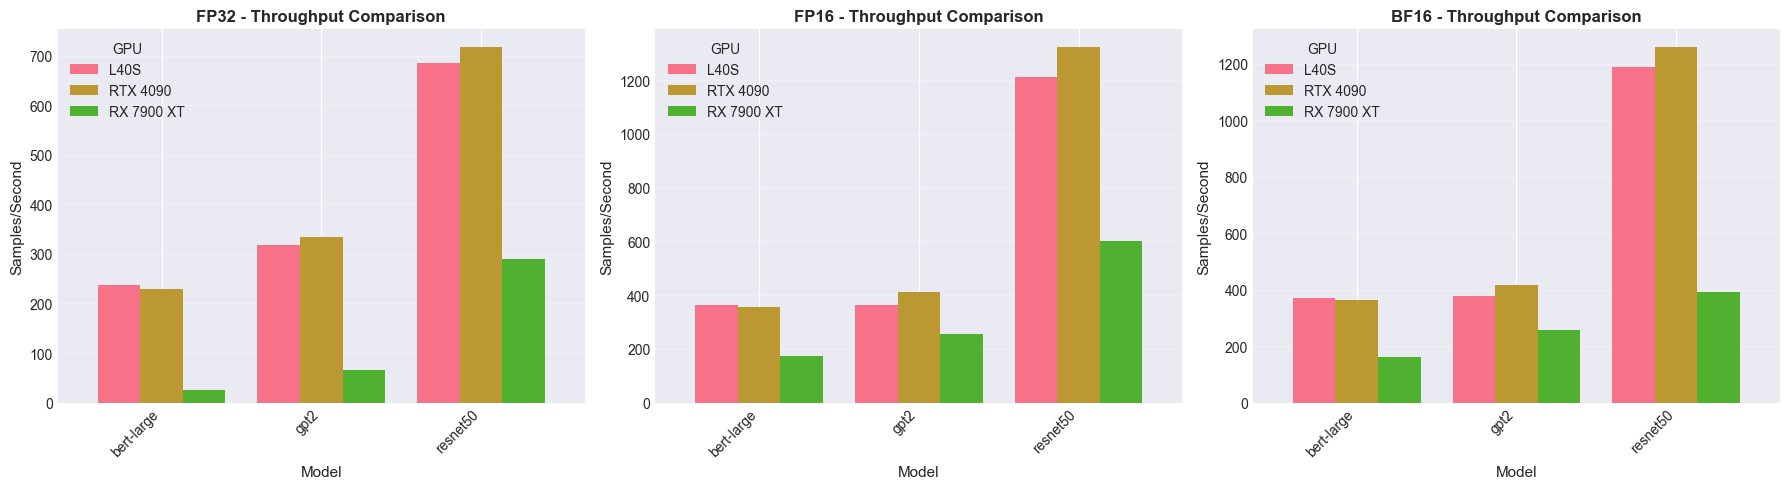

In [7]:
# Calculate mean throughput for each configuration
throughput_summary = df.groupby(['gpu_short_name', 'model', 'precision'])['samples_per_sec'].mean().reset_index()

# Create subplot for each precision
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
precisions = ['fp32', 'fp16', 'bf16']

for idx, prec in enumerate(precisions):
    prec_data = throughput_summary[throughput_summary['precision'] == prec]
    
    if len(prec_data) > 0:
        pivot = prec_data.pivot(index='model', columns='gpu_short_name', values='samples_per_sec')
        pivot.plot(kind='bar', ax=axes[idx], width=0.8)
        axes[idx].set_title(f'{prec.upper()} - Throughput Comparison', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Model', fontsize=11)
        axes[idx].set_ylabel('Samples/Second', fontsize=11)
        axes[idx].legend(title='GPU', loc='upper left')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('gpu_throughput_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Power Efficiency Comparison (Samples per Watt)

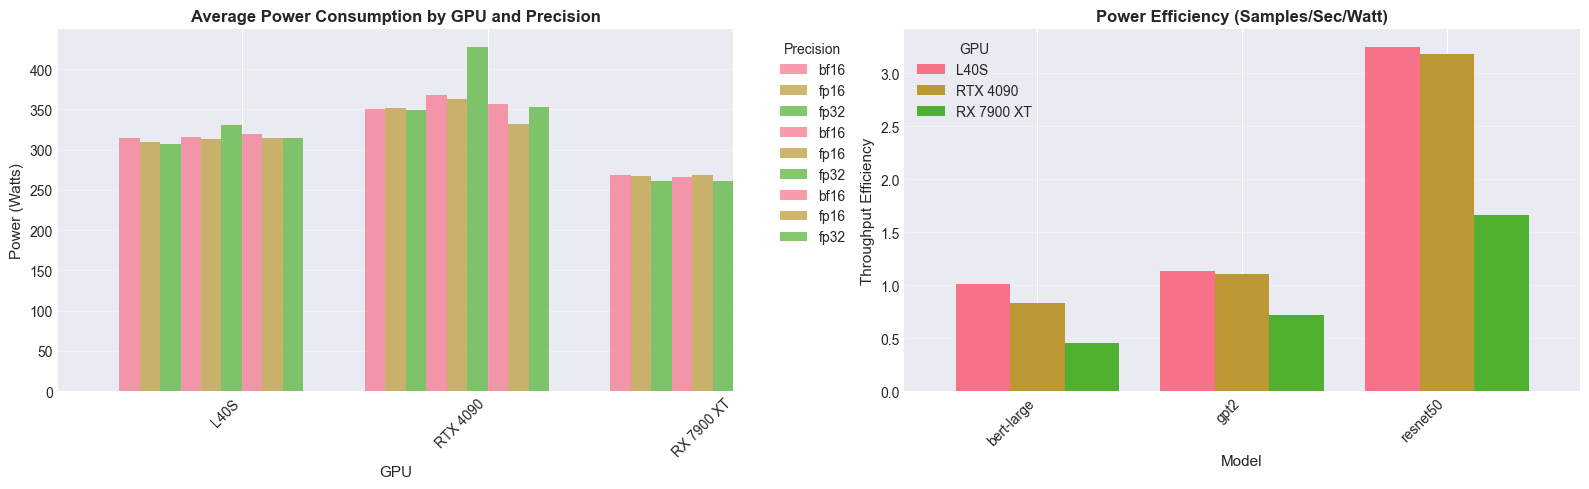


Power Efficiency Rankings (Samples/Sec/Watt):
gpu_short_name
L40S          1.8009
RTX 4090      1.7070
RX 7900 XT    0.9438
Name: throughput_efficiency, dtype: float64


In [8]:
# Calculate power efficiency
efficiency_summary = df.groupby(['gpu_short_name', 'model', 'precision']).agg({
    'throughput_efficiency': 'mean',
    'power_watts': 'mean',
    'samples_per_sec': 'mean'
}).reset_index()

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Power consumption by GPU and precision
for model in df['model'].unique():
    model_data = efficiency_summary[efficiency_summary['model'] == model]
    pivot = model_data.pivot_table(index='gpu_short_name', columns='precision', values='power_watts')
    pivot.plot(kind='bar', ax=axes[0], alpha=0.7, width=0.25, position=list(df['model'].unique()).index(model))

axes[0].set_title('Average Power Consumption by GPU and Precision', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPU', fontsize=11)
axes[0].set_ylabel('Power (Watts)', fontsize=11)
axes[0].legend(title='Precision', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Throughput efficiency (samples/sec/watt)
pivot_eff = efficiency_summary.pivot_table(index='model', columns='gpu_short_name', values='throughput_efficiency')
pivot_eff.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Power Efficiency (Samples/Sec/Watt)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('Throughput Efficiency', fontsize=11)
axes[1].legend(title='GPU', loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('power_efficiency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nPower Efficiency Rankings (Samples/Sec/Watt):")
eff_ranking = efficiency_summary.groupby('gpu_short_name')['throughput_efficiency'].mean().sort_values(ascending=False)
print(eff_ranking.round(4))

### 4.3 Memory Utilization Analysis

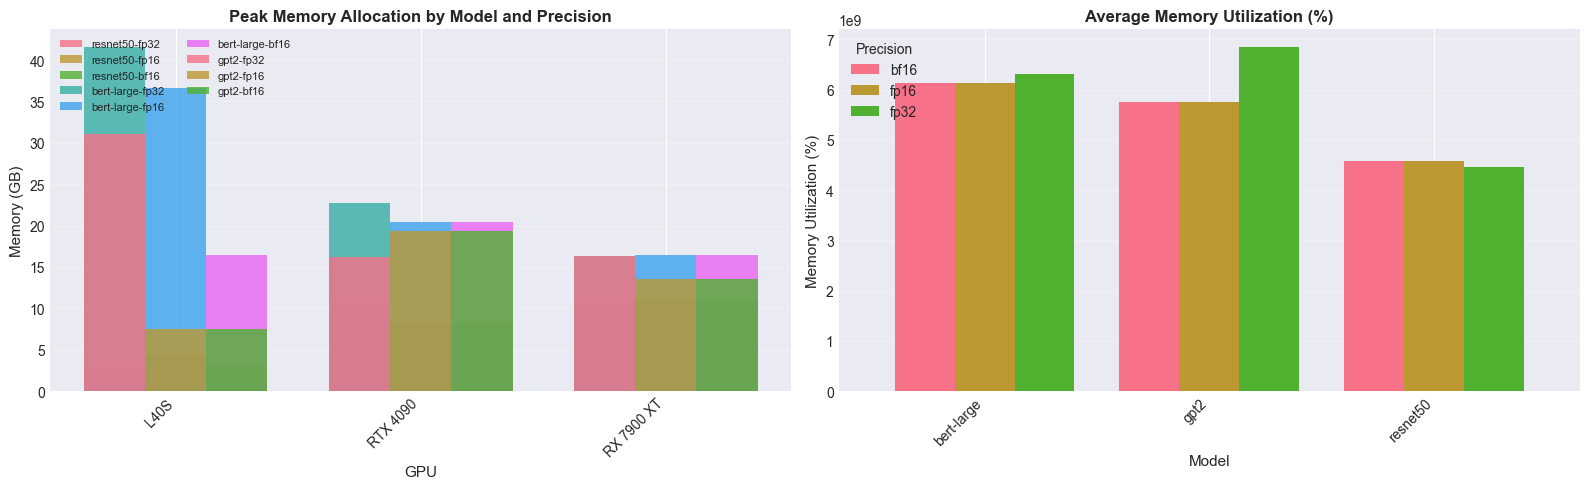


Memory savings from FP32 to FP16/BF16:

L40S - resnet50:
  FP16: -50.4% memory reduction (2.89GB → 4.35GB)
  BF16: -4.3% memory reduction (2.89GB → 3.02GB)

RX 7900 XT - resnet50:
  FP16: -3.6% memory reduction (10.65GB → 11.04GB)
  BF16: -3.6% memory reduction (10.65GB → 11.04GB)

RTX 4090 - resnet50:
  FP16: 21.4% memory reduction (10.63GB → 8.35GB)
  BF16: 21.4% memory reduction (10.63GB → 8.35GB)

L40S - bert-large:
  FP16: 12.1% memory reduction (41.62GB → 36.61GB)
  BF16: 60.5% memory reduction (41.62GB → 16.43GB)

RX 7900 XT - bert-large:
  FP16: -0.4% memory reduction (16.38GB → 16.45GB)
  BF16: -0.4% memory reduction (16.38GB → 16.45GB)

RTX 4090 - bert-large:
  FP16: 10.4% memory reduction (22.74GB → 20.39GB)
  BF16: 10.0% memory reduction (22.74GB → 20.47GB)

L40S - gpt2:
  FP16: 75.7% memory reduction (31.07GB → 7.55GB)
  BF16: 75.7% memory reduction (31.07GB → 7.55GB)

RX 7900 XT - gpt2:
  FP16: 17.2% memory reduction (16.30GB → 13.49GB)
  BF16: 17.2% memory reduction (16

In [9]:
# Memory analysis
mem_summary = df.groupby(['gpu_short_name', 'model', 'precision']).agg({
    'max_mem_alloc_gb': 'mean',
    'mem_util_percent': 'mean',
    'batch_size': 'first'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Memory usage by precision
for model in df['model'].unique():
    model_data = mem_summary[mem_summary['model'] == model]
    x_pos = np.arange(len(model_data['gpu_short_name'].unique()))
    width = 0.25
    
    for i, prec in enumerate(['fp32', 'fp16', 'bf16']):
        prec_data = model_data[model_data['precision'] == prec]
        if len(prec_data) > 0:
            axes[0].bar(x_pos + i*width, prec_data['max_mem_alloc_gb'], width, 
                       label=f'{model}-{prec}', alpha=0.8)

axes[0].set_title('Peak Memory Allocation by Model and Precision', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPU', fontsize=11)
axes[0].set_ylabel('Memory (GB)', fontsize=11)
axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(mem_summary['gpu_short_name'].unique(), rotation=45, ha='right')
axes[0].legend(loc='upper left', ncol=2, fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Memory utilization percentage
pivot_mem = mem_summary.pivot_table(index='model', columns='precision', values='mem_util_percent')
pivot_mem.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Average Memory Utilization (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('Memory Utilization (%)', fontsize=11)
axes[1].legend(title='Precision', loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('memory_utilization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMemory savings from FP32 to FP16/BF16:")
for model in df['model'].unique():
    for gpu in df['gpu_short_name'].unique():
        fp32_mem = mem_summary[(mem_summary['model'] == model) & 
                              (mem_summary['gpu_short_name'] == gpu) & 
                              (mem_summary['precision'] == 'fp32')]['max_mem_alloc_gb'].values
        
        if len(fp32_mem) > 0:
            print(f"\n{gpu} - {model}:")
            for prec in ['fp16', 'bf16']:
                prec_mem = mem_summary[(mem_summary['model'] == model) & 
                                      (mem_summary['gpu_short_name'] == gpu) & 
                                      (mem_summary['precision'] == prec)]['max_mem_alloc_gb'].values
                if len(prec_mem) > 0:
                    savings = (fp32_mem[0] - prec_mem[0]) / fp32_mem[0] * 100
                    print(f"  {prec.upper()}: {savings:.1f}% memory reduction ({fp32_mem[0]:.2f}GB → {prec_mem[0]:.2f}GB)")

## 5. Model-Specific Analysis

### 5.1 Training Loss Convergence

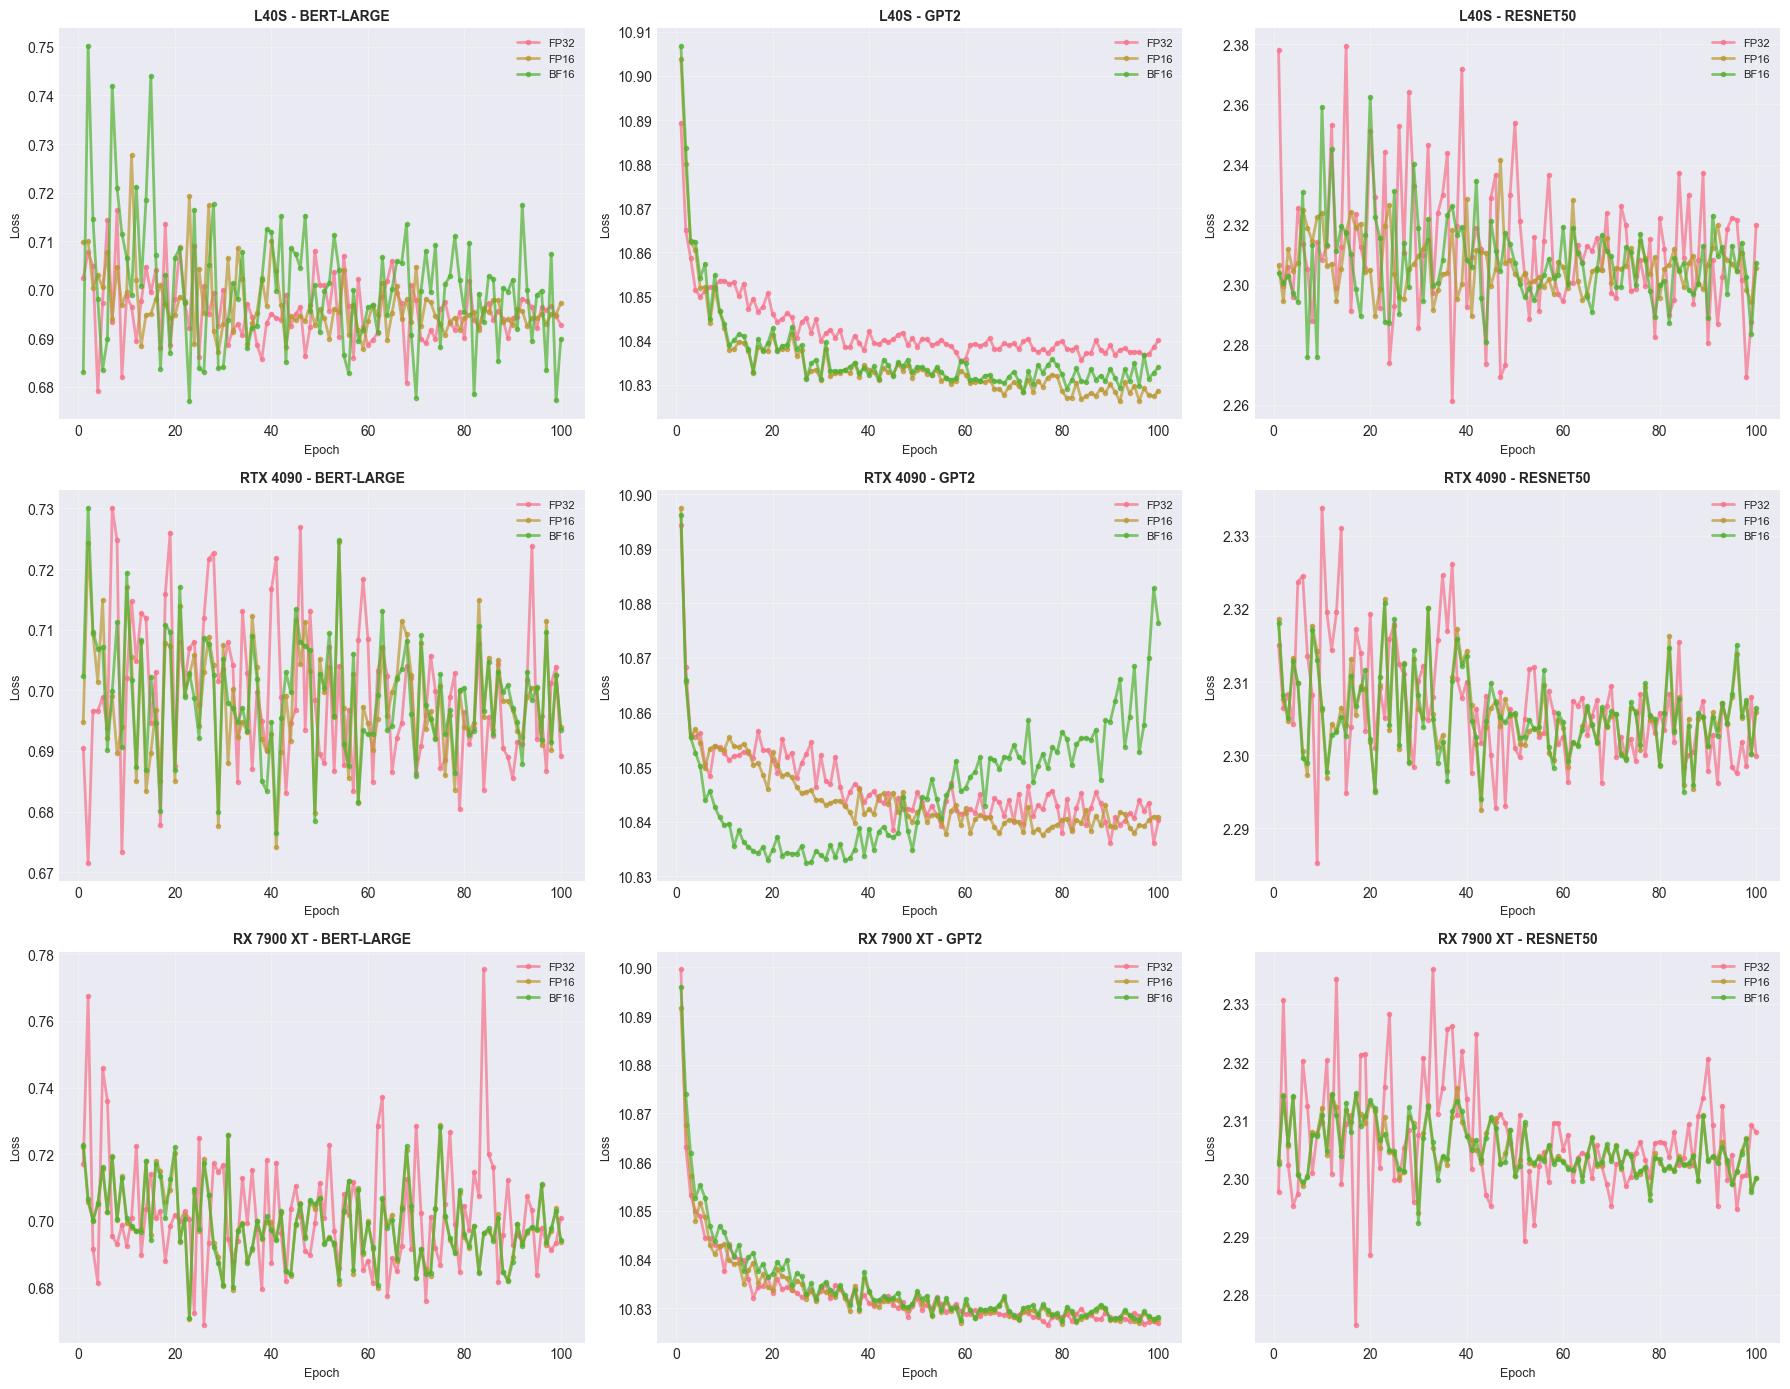

In [10]:
# Analyze loss convergence for each configuration
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_idx = 0
for gpu in sorted(df['gpu_short_name'].unique()):
    for model in sorted(df['model'].unique()):
        ax = axes[plot_idx]
        
        for precision in ['fp32', 'fp16', 'bf16']:
            subset = df[(df['gpu_short_name'] == gpu) & 
                       (df['model'] == model) & 
                       (df['precision'] == precision)]
            
            if len(subset) > 0:
                # Group by epoch and get mean loss
                epoch_loss = subset.groupby('epoch')['loss'].mean()
                ax.plot(epoch_loss.index, epoch_loss.values, label=precision.upper(), linewidth=2, marker='o', markersize=3, alpha=0.7)
        
        ax.set_title(f'{gpu} - {model.upper()}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Loss', fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1

plt.tight_layout()
plt.savefig('loss_convergence_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 GPU Utilization Patterns

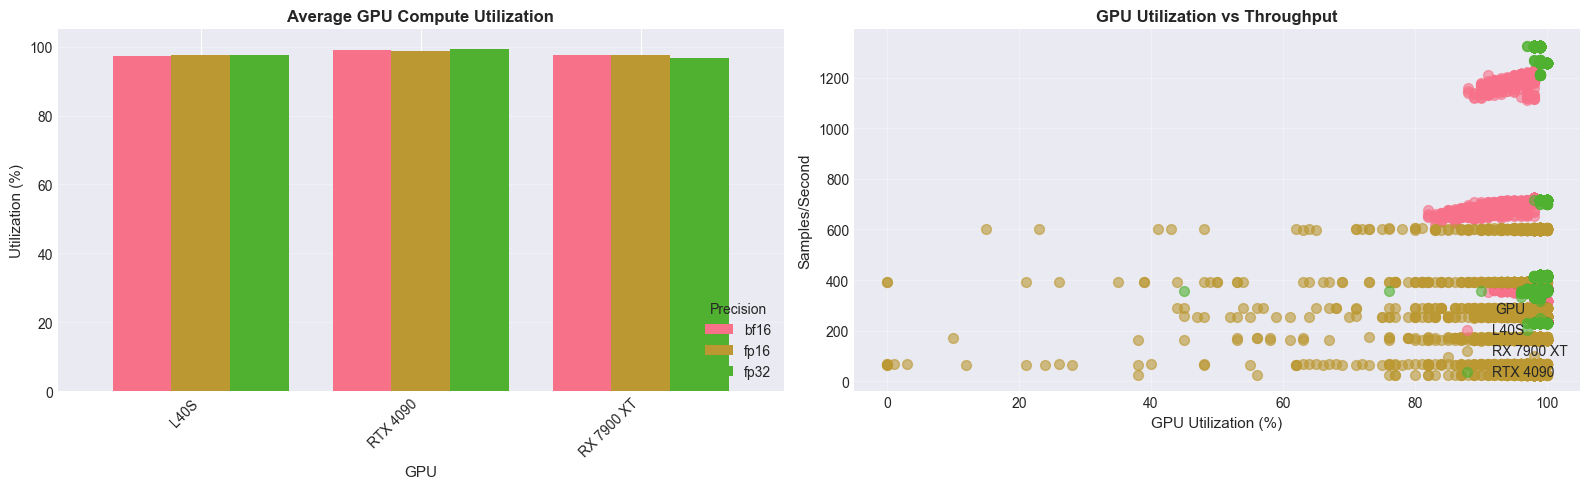


GPU Utilization Statistics:
                                    gpu_util_percent        mem_util_percent  \
                                                mean    std             mean   
gpu_short_name model      precision                                            
L40S           bert-large bf16                 99.09   0.49     8.144000e+01   
                          fp16                 99.80   0.40     9.240000e+01   
                          fp32                100.00   0.00     8.151000e+01   
               gpt2       bf16                 97.39   1.21     9.218000e+01   
                          fp16                 96.02   1.15     9.062000e+01   
                          fp32                100.00   0.08     9.363000e+01   
               resnet50   bf16                 95.20   2.23     8.148000e+01   
                          fp16                 97.15   0.60     9.209000e+01   
                          fp32                 92.52   4.05     8.737000e+01   
RTX 4090   

In [11]:
# GPU utilization analysis
util_summary = df.groupby(['gpu_short_name', 'model', 'precision']).agg({
    'gpu_util_percent': ['mean', 'std'],
    'mem_util_percent': ['mean', 'std']
}).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# GPU compute utilization
gpu_util = df.groupby(['gpu_short_name', 'precision'])['gpu_util_percent'].mean().reset_index()
pivot_gpu = gpu_util.pivot(index='gpu_short_name', columns='precision', values='gpu_util_percent')
pivot_gpu.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Average GPU Compute Utilization', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPU', fontsize=11)
axes[0].set_ylabel('Utilization (%)', fontsize=11)
axes[0].legend(title='Precision', loc='lower right')
axes[0].set_ylim([0, 105])
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Create scatter plot for efficiency
for gpu in df['gpu_short_name'].unique():
    gpu_data = df[df['gpu_short_name'] == gpu]
    axes[1].scatter(gpu_data['gpu_util_percent'], gpu_data['samples_per_sec'], 
                   label=gpu, alpha=0.6, s=50)

axes[1].set_title('GPU Utilization vs Throughput', fontsize=12, fontweight='bold')
axes[1].set_xlabel('GPU Utilization (%)', fontsize=11)
axes[1].set_ylabel('Samples/Second', fontsize=11)
axes[1].legend(title='GPU', loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gpu_utilization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGPU Utilization Statistics:")
print(util_summary)

## 6. Cross-GPU Performance Comparison

### 6.1 Overall Performance Rankings

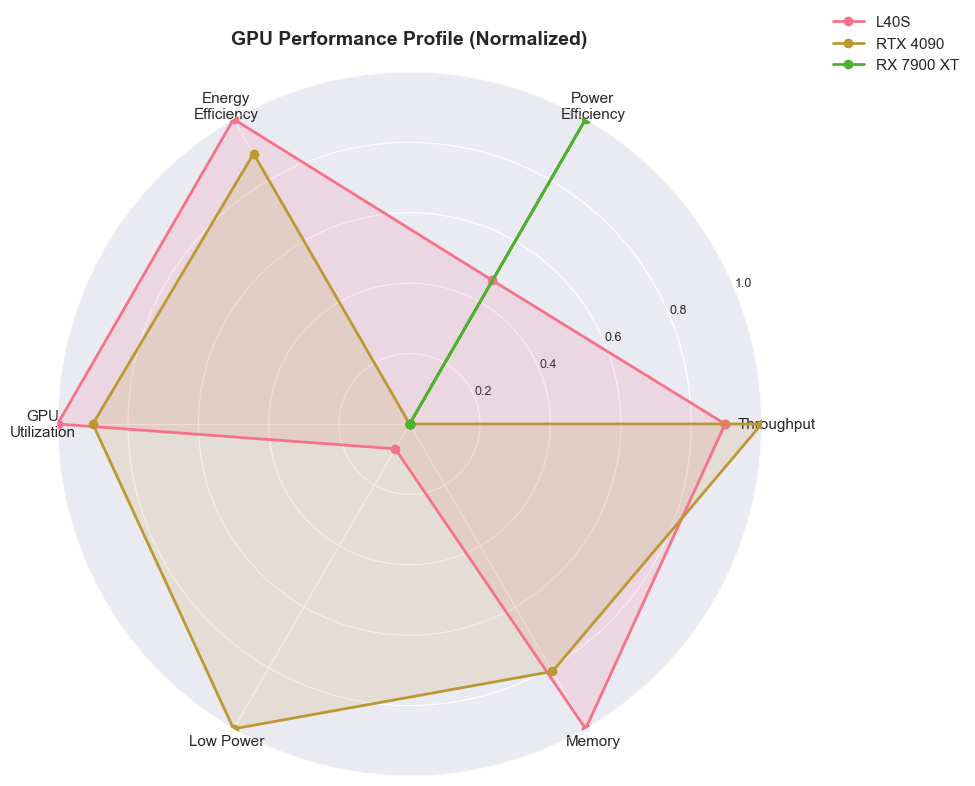


Raw Performance Metrics:
                samples_per_sec  power_watts  throughput_efficiency  \
gpu_short_name                                                        
L40S                    565.952      315.504                  1.794   
RTX 4090                600.796      361.303                  1.706   
RX 7900 XT              265.466      264.024                  1.017   

                energy_per_sample  gpu_util_percent  max_mem_alloc_gb  
gpu_short_name                                                         
L40S                        0.752            97.481            16.784  
RTX 4090                    0.852            99.036            16.204  
RX 7900 XT                  1.751            97.343            13.704  


In [12]:
# Create comprehensive ranking across all metrics
ranking_metrics = df.groupby('gpu_short_name').agg({
    'samples_per_sec': 'mean',
    'power_watts': 'mean',
    'throughput_efficiency': 'mean',
    'energy_per_sample': 'mean',
    'gpu_util_percent': 'mean',
    'max_mem_alloc_gb': 'mean'
}).round(3)

# Normalize metrics for radar chart (0-1 scale)
ranking_norm = ranking_metrics.copy()
for col in ranking_norm.columns:
    if col in ['power_watts', 'energy_per_sample']:  # Lower is better
        ranking_norm[col] = 1 - (ranking_norm[col] - ranking_norm[col].min()) / (ranking_norm[col].max() - ranking_norm[col].min())
    else:  # Higher is better
        ranking_norm[col] = (ranking_norm[col] - ranking_norm[col].min()) / (ranking_norm[col].max() - ranking_norm[col].min())

# Create radar chart
from math import pi

categories = ['Throughput', 'Power\nEfficiency', 'Energy\nEfficiency', 
              'GPU\nUtilization', 'Low Power', 'Memory']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for gpu in ranking_norm.index:
    values = ranking_norm.loc[gpu].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=gpu)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title('GPU Performance Profile (Normalized)', size=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('gpu_performance_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRaw Performance Metrics:")
print(ranking_metrics)

### 6.2 Best Configuration per Model

In [13]:
# Find best configuration for each model based on different criteria
best_configs = []

for model in df['model'].unique():
    model_data = df[df['model'] == model].groupby(['gpu_short_name', 'precision']).agg({
        'samples_per_sec': 'mean',
        'throughput_efficiency': 'mean',
        'energy_per_sample': 'mean',
        'power_watts': 'mean'
    }).reset_index()
    
    # Best throughput
    best_throughput = model_data.loc[model_data['samples_per_sec'].idxmax()]
    
    # Best efficiency (samples/watt)
    best_efficiency = model_data.loc[model_data['throughput_efficiency'].idxmax()]
    
    # Best energy per sample
    best_energy = model_data.loc[model_data['energy_per_sample'].idxmin()]
    
    best_configs.append({
        'model': model,
        'best_throughput': f"{best_throughput['gpu_short_name']} ({best_throughput['precision']}): {best_throughput['samples_per_sec']:.1f} samples/s",
        'best_efficiency': f"{best_efficiency['gpu_short_name']} ({best_efficiency['precision']}): {best_efficiency['throughput_efficiency']:.4f} samples/s/W",
        'best_energy': f"{best_energy['gpu_short_name']} ({best_energy['precision']}): {best_energy['energy_per_sample']:.4f} J/sample"
    })

best_config_df = pd.DataFrame(best_configs)
print("\nBest Configurations per Model:\n")
print(best_config_df.to_string(index=False))


Best Configurations per Model:

     model                   best_throughput                     best_efficiency                      best_energy
  resnet50 RTX 4090 (fp16): 1322.3 samples/s RTX 4090 (fp16): 3.9827 samples/s/W RTX 4090 (fp16): 0.2519 J/sample
bert-large      L40S (bf16): 368.6 samples/s     L40S (bf16): 1.1675 samples/s/W     L40S (bf16): 0.8566 J/sample
      gpt2  RTX 4090 (bf16): 417.7 samples/s     L40S (bf16): 1.1975 samples/s/W     L40S (bf16): 0.8352 J/sample


## 7. Statistical Analysis and Variance

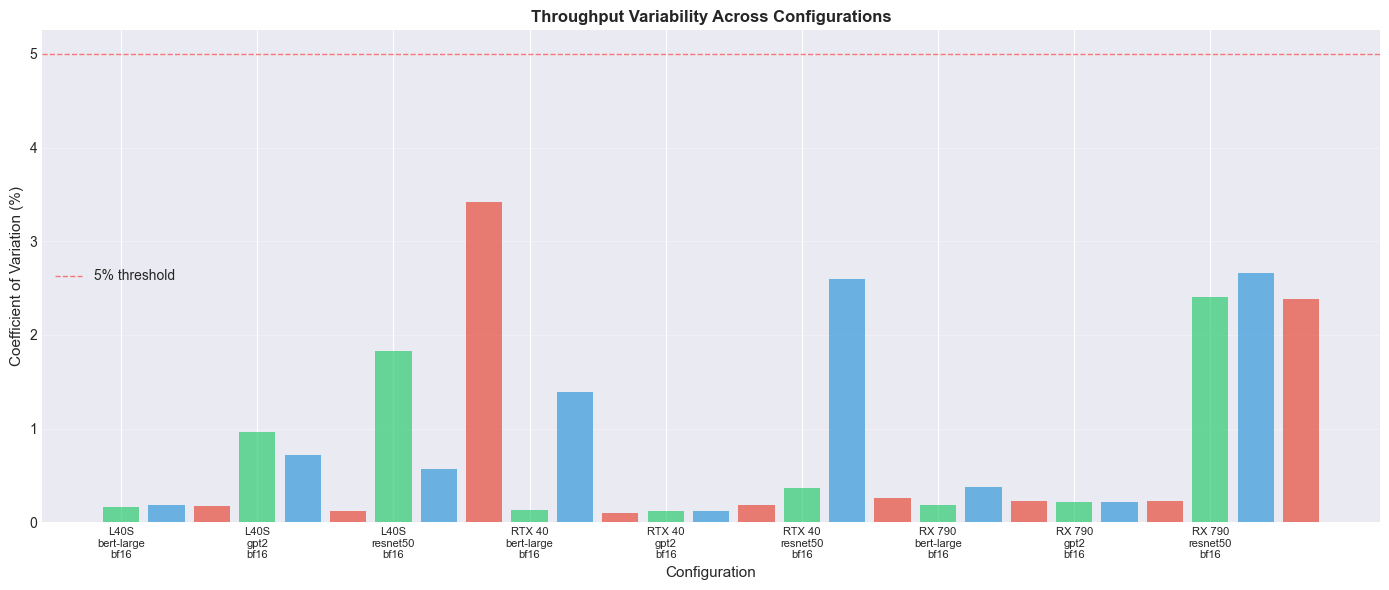


Top 10 Most Stable Configurations (lowest CV):
                                     samples_per_sec_mean  \
gpu_short_name model      precision                         
RTX 4090       bert-large fp32                    229.721   
L40S           gpt2       fp32                    317.799   
RTX 4090       gpt2       bf16                    417.745   
                          fp16                    411.027   
               bert-large bf16                    362.992   
L40S           bert-large bf16                    368.611   
                          fp32                    237.241   
                          fp16                    362.846   
RTX 4090       gpt2       fp32                    333.862   
RX 7900 XT     bert-large bf16                    161.429   

                                     samples_per_sec_std  throughput_cv  
gpu_short_name model      precision                                      
RTX 4090       bert-large fp32                     0.231           0.10

In [14]:
# Analyze performance variability
variance_analysis = df.groupby(['gpu_short_name', 'model', 'precision']).agg({
    'samples_per_sec': ['mean', 'std', 'min', 'max'],
    'epoch_time_sec': ['mean', 'std'],
    'power_watts': ['mean', 'std']
}).round(3)

variance_analysis.columns = ['_'.join(col).strip() for col in variance_analysis.columns.values]
variance_analysis['throughput_cv'] = (variance_analysis['samples_per_sec_std'] / 
                                     variance_analysis['samples_per_sec_mean'] * 100).round(2)

# Visualize coefficient of variation
fig, ax = plt.subplots(figsize=(14, 6))

cv_data = variance_analysis.reset_index()
x = np.arange(len(cv_data))
colors = {'fp32': '#e74c3c', 'fp16': '#3498db', 'bf16': '#2ecc71'}

for i, row in cv_data.iterrows():
    color = colors.get(row['precision'], '#95a5a6')
    ax.bar(i, row['throughput_cv'], color=color, alpha=0.7)

ax.set_xlabel('Configuration', fontsize=11)
ax.set_ylabel('Coefficient of Variation (%)', fontsize=11)
ax.set_title('Throughput Variability Across Configurations', fontsize=12, fontweight='bold')
ax.set_xticks(x[::3])  # Show every 3rd label to avoid crowding
ax.set_xticklabels([f"{row['gpu_short_name'][:6]}\n{row['model']}\n{row['precision']}" 
                    for _, row in cv_data.iloc[::3].iterrows()], fontsize=8, rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('performance_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Stable Configurations (lowest CV):")
print(variance_analysis.nsmallest(10, 'throughput_cv')[['samples_per_sec_mean', 'samples_per_sec_std', 'throughput_cv']])

## 8. Final Summary and Recommendations

In [15]:
# Generate comprehensive summary report
print("="*80)
print("MIXED PRECISION TRAINING ANALYSIS - EXECUTIVE SUMMARY")
print("="*80)

print("\n1. PRECISION IMPACT SUMMARY:")
print("-" * 80)
avg_speedup = speedup_df.groupby('precision')['throughput_speedup'].mean()
avg_energy_reduction = speedup_df.groupby('precision')['energy_reduction'].mean()
for prec in ['fp16', 'bf16']:
    if prec in avg_speedup.index:
        print(f"\n{prec.upper()} vs FP32:")
        print(f"  - Average Speedup: {avg_speedup[prec]:.2f}x")
        print(f"  - Average Energy Reduction: {avg_energy_reduction[prec]:.1f}%")
        print(f"  - Best Speedup: {speedup_df[speedup_df['precision']==prec]['throughput_speedup'].max():.2f}x "
              f"({speedup_df[speedup_df['precision']==prec].loc[speedup_df[speedup_df['precision']==prec]['throughput_speedup'].idxmax(), 'model']} on "
              f"{speedup_df[speedup_df['precision']==prec].loc[speedup_df[speedup_df['precision']==prec]['throughput_speedup'].idxmax(), 'gpu']})")

print("\n\n2. GPU PERFORMANCE RANKINGS:")
print("-" * 80)
gpu_scores = ranking_norm.mean(axis=1).sort_values(ascending=False)
for i, (gpu, score) in enumerate(gpu_scores.items(), 1):
    print(f"\n{i}. {gpu}")
    print(f"   Overall Score: {score:.3f}")
    print(f"   Avg Throughput: {ranking_metrics.loc[gpu, 'samples_per_sec']:.1f} samples/s")
    print(f"   Power Efficiency: {ranking_metrics.loc[gpu, 'throughput_efficiency']:.4f} samples/s/W")
    print(f"   Avg Power: {ranking_metrics.loc[gpu, 'power_watts']:.1f} W")

print("\n\n3. MODEL-SPECIFIC INSIGHTS:")
print("-" * 80)
for model in df['model'].unique():
    print(f"\n{model.upper()}:")
    model_speedup = speedup_df[speedup_df['model'] == model]
    if len(model_speedup) > 0:
        best = model_speedup.loc[model_speedup['throughput_speedup'].idxmax()]
        print(f"  - Best Mixed Precision Config: {best['gpu']} with {best['precision'].upper()}")
        print(f"  - Speedup: {best['throughput_speedup']:.2f}x over FP32")
        print(f"  - Energy Reduction: {best['energy_reduction']:.1f}%")

print("\n\n4. KEY RECOMMENDATIONS:")
print("-" * 80)
print("\n✓ For Maximum Throughput:")
max_throughput_config = df.loc[df['samples_per_sec'].idxmax()]
print(f"  Use {max_throughput_config['gpu_short_name']} with {max_throughput_config['precision'].upper()} "
      f"for {max_throughput_config['model']} ({max_throughput_config['samples_per_sec']:.1f} samples/s)")

print("\n✓ For Best Power Efficiency:")
max_eff_config = df.loc[df['throughput_efficiency'].idxmax()]
print(f"  Use {max_eff_config['gpu_short_name']} with {max_eff_config['precision'].upper()} "
      f"for {max_eff_config['model']} ({max_eff_config['throughput_efficiency']:.4f} samples/s/W)")

print("\n✓ For Lowest Energy Consumption:")
min_energy_config = df.loc[df['energy_per_sample'].idxmin()]
print(f"  Use {min_energy_config['gpu_short_name']} with {min_energy_config['precision'].upper()} "
      f"for {min_energy_config['model']} ({min_energy_config['energy_per_sample']:.4f} J/sample)")

print("\n" + "="*80)
print("Analysis complete! All visualizations saved.")
print("="*80)

MIXED PRECISION TRAINING ANALYSIS - EXECUTIVE SUMMARY

1. PRECISION IMPACT SUMMARY:
--------------------------------------------------------------------------------

FP16 vs FP32:
  - Average Speedup: 2.40x
  - Average Energy Reduction: 46.2%
  - Best Speedup: 6.65x (bert-large on RX 7900 XT)

BF16 vs FP32:
  - Average Speedup: 2.28x
  - Average Energy Reduction: 42.9%
  - Best Speedup: 6.23x (bert-large on RX 7900 XT)


2. GPU PERFORMANCE RANKINGS:
--------------------------------------------------------------------------------

1. RTX 4090
   Overall Score: 0.766
   Avg Throughput: 600.8 samples/s
   Power Efficiency: 1.7060 samples/s/W
   Avg Power: 361.3 W

2. L40S
   Overall Score: 0.741
   Avg Throughput: 566.0 samples/s
   Power Efficiency: 1.7940 samples/s/W
   Avg Power: 315.5 W

3. RX 7900 XT
   Overall Score: 0.167
   Avg Throughput: 265.5 samples/s
   Power Efficiency: 1.0170 samples/s/W
   Avg Power: 264.0 W


3. MODEL-SPECIFIC INSIGHTS:
-----------------------------------

## 9. Export Summary Data for Thesis

In [16]:
# Export key tables for thesis
summary.to_csv('training_summary_statistics.csv', index=False)
speedup_df.to_csv('precision_speedup_analysis.csv', index=False)
ranking_metrics.to_csv('gpu_performance_rankings.csv')
variance_analysis.to_csv('performance_variance_analysis.csv')

print("Summary data exported to CSV files:")
print("  - training_summary_statistics.csv")
print("  - precision_speedup_analysis.csv")
print("  - gpu_performance_rankings.csv")
print("  - performance_variance_analysis.csv")
print("\nAll visualizations saved as PNG files in the current directory.")

Summary data exported to CSV files:
  - training_summary_statistics.csv
  - precision_speedup_analysis.csv
  - gpu_performance_rankings.csv
  - performance_variance_analysis.csv

All visualizations saved as PNG files in the current directory.
